# Customer Churn Prediction using Artificial Neural Network (ANN)
**Course:** Advanced Deep Learning (DL-501)  
**Assignment 01** — Full Pipeline: EDA → Preprocessing → ANN → Training → Evaluation

**Student Name:** _____________  
**Roll No / Batch:** _____________

---
### Random Seed Lock (Academic Policy Requirement)
As per the assignment's academic policy, we lock all random seeds globally so results are reproducible across different machines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# ---- LOCK RANDOM SEEDS GLOBALLY (Academic Policy Requirement) ----
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Part 1 — Data Exploration (EDA)

In [2]:
# Standard Telco Customer Churn Dataset (public IBM sample dataset, widely used for this exact assignment)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 1. Display first five records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 2. Inspect dataset metadata (structural data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# 3. Locate and count all missing / corrupted field entries per column
print("Standard NaN check:\n", df.isnull().sum())

# NOTE: TotalCharges is loaded as 'object' dtype (string), not float — this hides blank-string
# entries that pandas' isnull() cannot detect. This is the classic hidden-dirty-data trap
# in this dataset (Part 2 will fix it).
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Blank-string entries in TotalCharges:", (df['TotalCharges'].str.strip() == '').sum())

Standard NaN check:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges dtype: object
Blank-string entries in TotalCharges: 11


In [5]:
# 4. Descriptive statistics (mean, std, quartiles, min, max)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_364/352481792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#1f77b4', '#ff7f0e'])


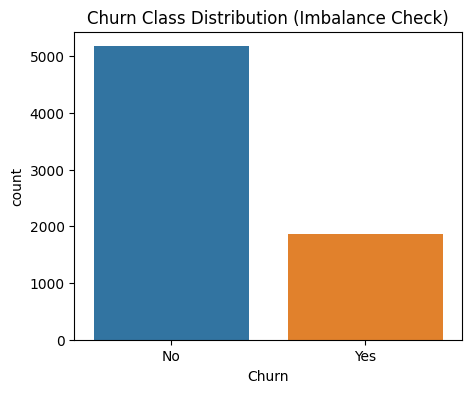

In [6]:
# 5. Target variable distribution (class imbalance check)
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title("Churn Class Distribution (Imbalance Check)")
plt.show()

## Part 2 — Data Preprocessing Pipeline

In [7]:
df_clean = df.copy()

# --- Missing Value Remediation ---
# Convert blank-string entries in TotalCharges to NaN, then coerce to numeric
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print("Missing values in TotalCharges after conversion:", df_clean['TotalCharges'].isnull().sum())

# Median imputation (robust to outliers, better than mean for skewed billing data)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())
print("Missing values after median imputation:", df_clean['TotalCharges'].isnull().sum())

Missing values in TotalCharges after conversion: 11
Missing values after median imputation: 0


In [8]:
# --- Dimensional Pruning ---
# customerID has zero predictive variance (a unique ID per row) — drop it
df_clean.drop('customerID', axis=1, inplace=True)

In [9]:
# --- Target Variable Conversion ---
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

In [10]:
# --- Categorical Variable Transformations ---

# Identify categorical columns (excluding target)
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

# Separate binary (2-value) vs multi-class (3+ value) categorical columns
binary_cols = [col for col in categorical_cols if df_clean[col].nunique() == 2]
multiclass_cols = [col for col in categorical_cols if df_clean[col].nunique() > 2]

print("Binary columns (Label Encoding):", binary_cols)
print("Multi-class columns (One-Hot Encoding):", multiclass_cols)

# Binary encoding for 2-state features
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-hot encoding for 3+ value nominal features
df_clean = pd.get_dummies(df_clean, columns=multiclass_cols, drop_first=True)

# Ensure all bool columns from get_dummies are converted to int (0/1) for the ANN
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

df_clean.head()

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Binary columns (Label Encoding): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class columns (One-Hot Encoding): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [11]:
# --- Split features and target ---
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

print("Final feature count (Input Layer size):", X.shape[1])

Final feature count (Input Layer size): 30


In [12]:
# --- Validation Partitioning: 80% train / 20% test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 30) Test shape: (1409, 30)


In [13]:
# --- Feature Scaling (Z-score standardization) ---
# Fit scaler on TRAINING data only to avoid data leakage, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Part 3 — Artificial Neural Network Architecture

In [14]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    Dense(32, activation='relu', input_shape=(n_features,)),  # Hidden Layer 1
    Dense(16, activation='relu'),                              # Hidden Layer 2
    Dense(1, activation='sigmoid')                              # Output Layer
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Part 4 & 5 — Optimization Configuration & Training Execution

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7772 - loss: 0.4708 - val_accuracy: 0.7888 - val_loss: 0.4506
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8001 - loss: 0.4217 - val_accuracy: 0.7844 - val_loss: 0.4461
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8012 - loss: 0.4126 - val_accuracy: 0.7791 - val_loss: 0.4450
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8056 - loss: 0.4076 - val_accuracy: 0.7782 - val_loss: 0.4448
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8085 - loss: 0.4040 - val_accuracy: 0.7791 - val_loss: 0.4446
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8116 - loss: 0.4011 - val_accuracy: 0.7817 - val_loss: 0.4448
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8150 - loss: 0.3987 - val_accuracy: 0.7808 - val_loss: 0.4455
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8178 - loss: 0.3966 - val_accuracy: 

## Part 6 — Model Evaluation on Test Set

In [17]:
# Predict probabilities, then threshold at 0.5
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-Score      : {f1:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy : 0.7729
Precision     : 0.5742
Recall        : 0.5588
F1-Score      : 0.5664


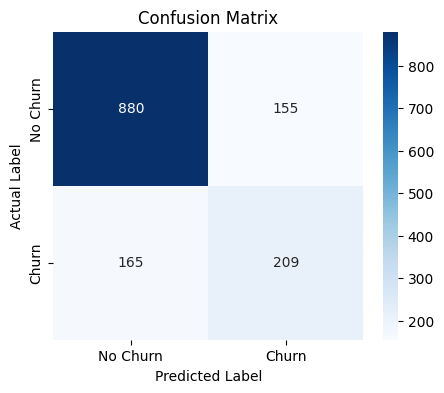

Confusion Matrix:
 [[880 155]
 [165 209]]


In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:\n", cm)

In [19]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
       Churn       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



## Part 7 — Training Visualization (Learning Curves)

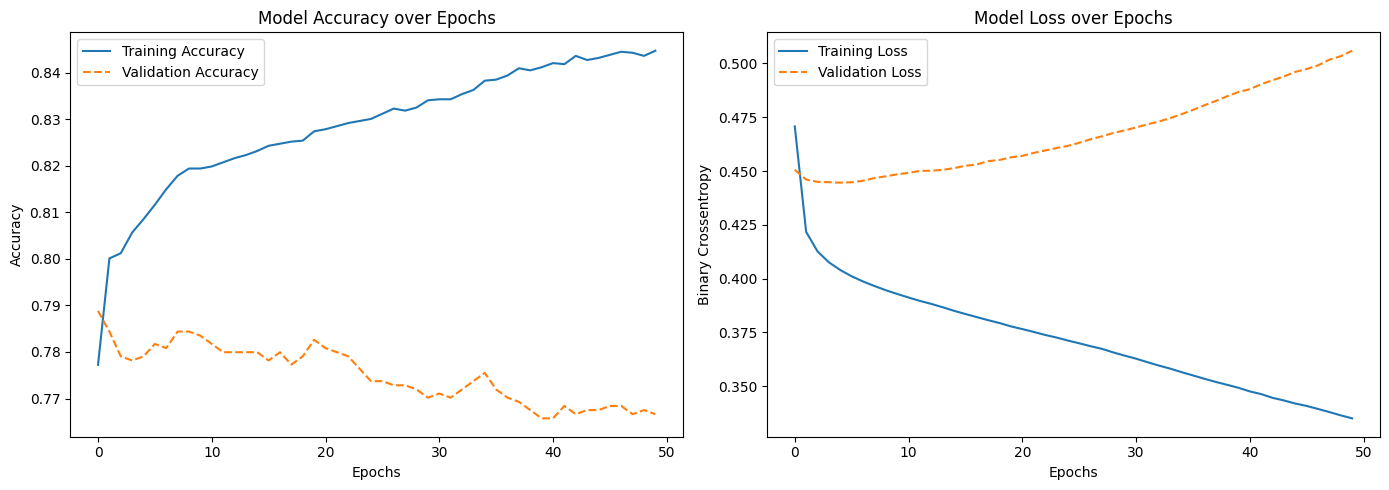

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss curve
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Binary Crossentropy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 8 — Final Predictions vs Actual Labels

In [21]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Predicted_Probability': y_pred_prob.flatten().round(4)
})
results_df['Match'] = results_df['Actual'] == results_df['Predicted']

print(f"Correct predictions: {results_df['Match'].sum()} / {len(results_df)}")
results_df.head(15)

Correct predictions: 1089 / 1409


,Actual,Predicted,Predicted_Probability,Match
0,0,0,0.0322,True
1,0,1,0.7888,False
2,0,0,0.0100,True
3,0,0,0.4724,True
4,0,0,0.0043,True
5,0,1,0.8649,False
6,0,0,0.2620,True
7,0,0,0.0772,True
8,0,0,0.0002,True
9,1,1,0.6099,True


## Save Trained Model (Submission Deliverable)

In [22]:
model.save('churn_ann_model.keras')
print("Model saved as churn_ann_model.keras")

Model saved as churn_ann_model.keras
